In [1]:
import matplotlib.pyplot as plt 
import numpy as np
import os 
import sys 

parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, parent_dir)

from utils.ppnet_utils import initialize_network, custom_se
from utils.gen_utils import load_config
from utils.load_data_utils import load_sampled_input_data

In [2]:
config = load_config('config.yaml')

# initialise the network and use the same data to solve wls and GAT for the SE 
net = initialize_network(net_name=config['data']['net_name'],
                         load_std=config['data']['load_std'])

num_samples = config['data']['num_samples']
num_buses = len(net.bus)

# use same data for all: wls, gat, tapsegnn
sampled_input_data = load_sampled_input_data(sc_type=config['data']['scenario_type'], 
                                                   net=net, 
                                                   num_samples=config['data']['num_samples'], 
                                                   noise=config['data']['noise'])


Network: net_4bus is selected 

Net net_4bus has 4 nodes and 4 edges. 

Selecting all the MV/LV transformers in the network 

>>> Using relative noise of 0.0033333333333333335% on voltage and 1.6666666666666667% on power measurements.
Scaling inputs...
Number of V, P measurements 5 out of 8

Number of P_to, Q_to, P_from, Q_from measurements 2 out of 4

Sparsity of PV measurements at buses = 0.5%
Sparsity of P+ measurements at branches = 0.5


ignore sparsity 

In [3]:
import logging
from tqdm import tqdm

# Disable pandapower state estimation debug messages
logging.getLogger('pandapower.estimation.state_estimation').setLevel(logging.WARNING)

# Or disable all pandapower debug messages
logging.getLogger('pandapower').setLevel(logging.WARNING)

# WLS estimates
wls_est_v = np.zeros((num_buses, num_samples))
wls_est_a = np.zeros((num_buses, num_samples))
label_v_pfr = np.zeros((num_buses, num_samples))
label_a_pfr = np.zeros((num_buses, num_samples))

for sample_id in tqdm(range(100)):
    label_v_pfr[:, sample_id] = sampled_input_data['res_bus_vm_pu'][:,sample_id]
    label_a_pfr[:, sample_id] = sampled_input_data['res_bus_va_deg'][:,sample_id]
    
    pfr_dict = {'vm_pfr': sampled_input_data['res_bus_vm_pu'][:,sample_id], 
                'p_pfr': sampled_input_data['res_bus_p_mw'][:,sample_id],
                'p_pfr_line': sampled_input_data['edge_p_pfr_edge'][:,sample_id]}
    
    net_meas = custom_se(net=net, pfr_dict=pfr_dict, se_iter=20) 
                         
    wls_est_v[:, sample_id] = net_meas.res_bus_est.vm_pu.values
    wls_est_a[:, sample_id] = net_meas.res_bus_est.va_degree.values 


  0%|          | 0/100 [00:00<?, ?it/s]WARNING:pandapower.estimation.state_estimation:WARNING: Gain matrix is ill-conditioned: 1.16E+18


State estimation failed. Retrying... Remaining attempts: 19
State estimation failed. Retrying... Remaining attempts: 18
State estimation failed. Retrying... Remaining attempts: 17
State estimation failed. Retrying... Remaining attempts: 16


State estimation failed. Retrying... Remaining attempts: 15
State estimation failed. Retrying... Remaining attempts: 14


State estimation failed. Retrying... Remaining attempts: 13
State estimation failed. Retrying... Remaining attempts: 12
State estimation failed. Retrying... Remaining attempts: 11
State estimation failed. Retrying... Remaining attempts: 10


State estimation failed. Retrying... Remaining attempts: 9
State estimation failed. Retrying... Remaining attempts: 8


State estimation failed. Retrying... Remaining attempts: 7
State estimation failed. Retrying... Remaining attempts: 6
State estimation failed. Retrying... Remaining attempts: 5
State estimation failed. Retrying... Remaining attempts: 4


State estimation failed. Retrying... Remaining attempts: 3
State estimation failed. Retrying... Remaining attempts: 2


  0%|          | 0/100 [00:00<?, ?it/s]


State estimation failed. Retrying... Remaining attempts: 1
Total number of measurements = 11 and number of measurements should be at least 7


ValueError: could not broadcast input array from shape (0,) into shape (4,)

In [ ]:
wls_rmse_v = np.sqrt(np.mean((label_v_pfr - wls_est_v)**2, axis=1))
wls_rmse_a = np.sqrt(np.mean((label_a_pfr - wls_est_a)**2, axis=1))
wls_rmse_v, wls_rmse_a


(array([5.51918327e-06, 5.71315245e-06, 5.48352406e-06, 4.87444106e-06]),
 array([0.        , 0.00086751, 0.00111433, 0.05992136]))

In [5]:
import torch
from utils.model_utils import initialize_model, get_eval_results
from src.dataset.custom_dataset import NodeEdgeTapDatasetV2
from utils.gen_utils import dataset_splitter
from training.trainer import trainer

device='cpu'

dataset = NodeEdgeTapDatasetV2(model_name=config['model']['name'], sampled_input_data=sampled_input_data)

all_loaders, plot_loader = dataset_splitter(dataset,
                                            batch_size=config['loader']['batch_size'],
                                            split_list=config['loader']['split_list'])

# use GAT 
model_GAT = initialize_model(model_name="GATRegressor",
                            dataset=dataset,
                            node_out_features=config['model']['node_out_features'],
                            list_node_hidden_features=config['model']['list_node_hidden_features'],
                            k_hop_node=config['model']['k_hop_node'],
                            edge_out_features=config['model']['edge_out_features'], 
                            list_edge_hidden_features=config['model']['list_edge_hidden_features'],
                            k_hop_edge=config['model']['k_hop_edge'],
                            trafo_hop=config['model']['trafo_hop'],
                            edge_index_list=sampled_input_data['edge_index'],
                            gat_out_features=config['model']['gat_out_features'],
                            gat_head=config['model']['gat_head'],
                            bias=config['model']['bias'], 
                            normalize=config['model']['normalize'], 
                            device=device,  
                            ).to(device)    

total_params = sum(p.numel() for p in model_GAT.parameters() if p.requires_grad)

print(f'Total number of parameters of model {model_GAT}: {total_params}')

optimizer_GAT = torch.optim.Adam(model_GAT.parameters(),lr=config['training']['lr'], weight_decay=config['training']['weight_decay'])

schedular_GAT = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer_GAT, 
                                                    mode='min',
                                                    factor=0.1, 
                                                    # patience=1,
                                                    min_lr=config['training']['schedular_min_lr'])

# GAT 
all_losses_GAT = trainer(model=model_GAT, 
                    train_loader=all_loaders[0], 
                    val_loader=all_loaders[1], 
                    test_loader=all_loaders[2], 
                    optimizer=optimizer_GAT,
                    schedular=schedular_GAT,
                    num_epoch=config['training']['num_epochs'],
                    early_stopping=config['training']['early_stopping'],
                    val_patience=config['training']['val_patience'],  
                    device=device)

results, pred_se_va, label_se_va = get_eval_results(test_loader=all_loaders[2],
                                tap_weight=config['training']['loss_tap_weight'], 
                                trained_model=model_GAT, 
                                scaler=sampled_input_data['scaler_y_label'], 
                                output_pred_va=True)

Dataset for MultiTapSEGNN selected!


 Directed power flows accounted in dataset...


 get_edge_index_lu handling dictionary of tensors...

Total number of parameters of model GATRegressor(
  (gatconv): GATConv(2, 32, heads=1)
  (mlp_gat): Sequential(
    (0): Linear(in_features=32, out_features=2, bias=True)
  )
): 450
At epoch: 0, 	 training loss: 8.078e-01,                     	 validation loss: 3.603e-01 	 lr: 1.00e-02 	 grad_norm: 1.138e+00
At epoch: 50, 	 training loss: 3.080e-01,                     	 validation loss: 2.806e-01 	 lr: 1.00e-03 	 grad_norm: 8.701e-01
At epoch: 100, 	 training loss: 3.075e-01,                     	 validation loss: 2.803e-01 	 lr: 1.00e-04 	 grad_norm: 6.805e-01
At epoch: 150, 	 training loss: 3.085e-01,                     	 validation loss: 2.803e-01 	 lr: 1.00e-04 	 grad_norm: 7.569e-01
At epoch: 200, 	 training loss: 3.091e-01,                     	 validation loss: 2.803e-01 	 lr: 1.00e-04 	 grad_norm: 8.096e-01
At epoch: 250, 	 training loss:

In [6]:
pred_se_va.shape

torch.Size([256, 2])

In [7]:
40/10

4.0

In [8]:
num_graphs = int(pred_se_va.shape[0]/num_buses)

# remove offset 
pred_se_va = pred_se_va - 10.0
label_se_va = label_se_va - 10.0 

pred_se_va_rs = torch.reshape(pred_se_va, (num_graphs,num_buses,-1))
label_se_va_rs = torch.reshape(label_se_va, (num_graphs,num_buses,-1))

error_pl = (pred_se_va_rs - label_se_va_rs)
error_v = error_pl[:,:,0].T 
error_a = error_pl[:,:,1].T

error_v = error_v ** 2
error_a = error_a ** 2 

mean_error_v = error_v.mean(dim=1)
gat_rmse_v = torch.sqrt(mean_error_v)

mean_error_a = error_a.mean(dim=1)
gat_rmse_a = torch.sqrt(mean_error_a)

In [9]:
# use TapSEGNN 
model = initialize_model(model_name="NEGATRegressor",
                        dataset=dataset,
                        node_out_features=config['model']['node_out_features'],
                        list_node_hidden_features=config['model']['list_node_hidden_features'],
                        k_hop_node=config['model']['k_hop_node'],
                        edge_out_features=config['model']['edge_out_features'], 
                        list_edge_hidden_features=config['model']['list_edge_hidden_features'],
                        k_hop_edge=config['model']['k_hop_edge'],
                        trafo_hop=config['model']['trafo_hop'],
                        edge_index_list=sampled_input_data['edge_index'],
                        gat_out_features=config['model']['gat_out_features'],
                        gat_head=config['model']['gat_head'],
                        bias=config['model']['bias'], 
                        normalize=config['model']['normalize'], 
                        device=device,
                        ).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total number of parameters of model {model}: {total_params}')

optimizer = torch.optim.Adam(model.parameters(),
                            lr=config['training']['lr'], 
                            weight_decay=config['training']['weight_decay'])
        
schedular = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer, 
                                                    mode='min',
                                                    factor=0.1, 
                                                    patience=1,
                                                    min_lr=config['training']['schedular_min_lr'])

all_losses = trainer(model=model, 
                    train_loader=all_loaders[0], 
                    val_loader=all_loaders[1], 
                    test_loader=all_loaders[2], 
                    optimizer=optimizer,
                    schedular=schedular,
                    num_epoch=config['training']['num_epochs'],
                    early_stopping=config['training']['early_stopping'],
                    val_patience=config['training']['val_patience'], 
                    tap_weight=config['training']['loss_tap_weight'], 
                    device=device)

results_tapse, pred_se_va_tapse, label_se_va_tapse  = get_eval_results(test_loader=all_loaders[2],
                                tap_weight=config['training']['loss_tap_weight'], 
                            trained_model=model, 
                            scaler=sampled_input_data['scaler_y_label'], 
                            output_pred_va=True)

Total number of parameters of model NEGATRegressor(
  (node_layers): ModuleList(
    (0): TAGConv(2, 64, K=3)
    (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (fc_node): Linear(in_features=64, out_features=32, bias=True)
  (edge_layers): ModuleList(
    (0): ModuleList(
      (0-1): 2 x TAGConv(6, 128, K=1)
    )
  )
  (edge_biases): ParameterList(  (0): Parameter containing: [torch.float32 of size 128])
  (fc_edge): Linear(in_features=128, out_features=64, bias=True)
  (gatconv): GATConv(32, 32, heads=1)
  (mlp_gat): Sequential(
    (0): Linear(in_features=32, out_features=2, bias=True)
  )
): 17506
At epoch: 0, 	 training loss: 2.295e+00,                     	 validation loss: 9.046e-01 	 lr: 1.00e-02 	 grad_norm: 2.325e+01
At epoch: 50, 	 training loss: 6.710e-04,                     	 validation loss: 8.883e-04 	 lr: 1.00e-04 	 grad_norm: 2.978e+00
At epoch: 100, 	 training loss: 9.536e-04,                     	 validation loss: 1.349e-03 	 lr: 1.00e-04 	 grad_no

In [10]:
# remove offset 
pred_se_va = pred_se_va_tapse - 10.0 
label_se_va = label_se_va_tapse - 10.0 

pred_se_va_rs = torch.reshape(pred_se_va, (num_graphs,num_buses,-1))
label_se_va_rs = torch.reshape(label_se_va, (num_graphs,num_buses,-1))

# Calculate errors for voltage (index 0) and angle (index 1) 
error_v = pred_se_va_rs[:, :, 0] - label_se_va_rs[:, :, 0]  # Shape: (batch_size, num_buses)
error_a = pred_se_va_rs[:, :, 1] - label_se_va_rs[:, :, 1]  # Shape: (batch_size, num_buses)

error_v = error_v ** 2
error_a = error_a ** 2 

mean_error_v = error_v.mean(dim=0)
tapsegnn_rmse_v = torch.sqrt(mean_error_v)

mean_error_a = error_a.mean(dim=0)
tapsegnn_rmse_a = torch.sqrt(mean_error_a)

DEBUG:matplotlib.pyplot:Loaded backend inline version unknown.


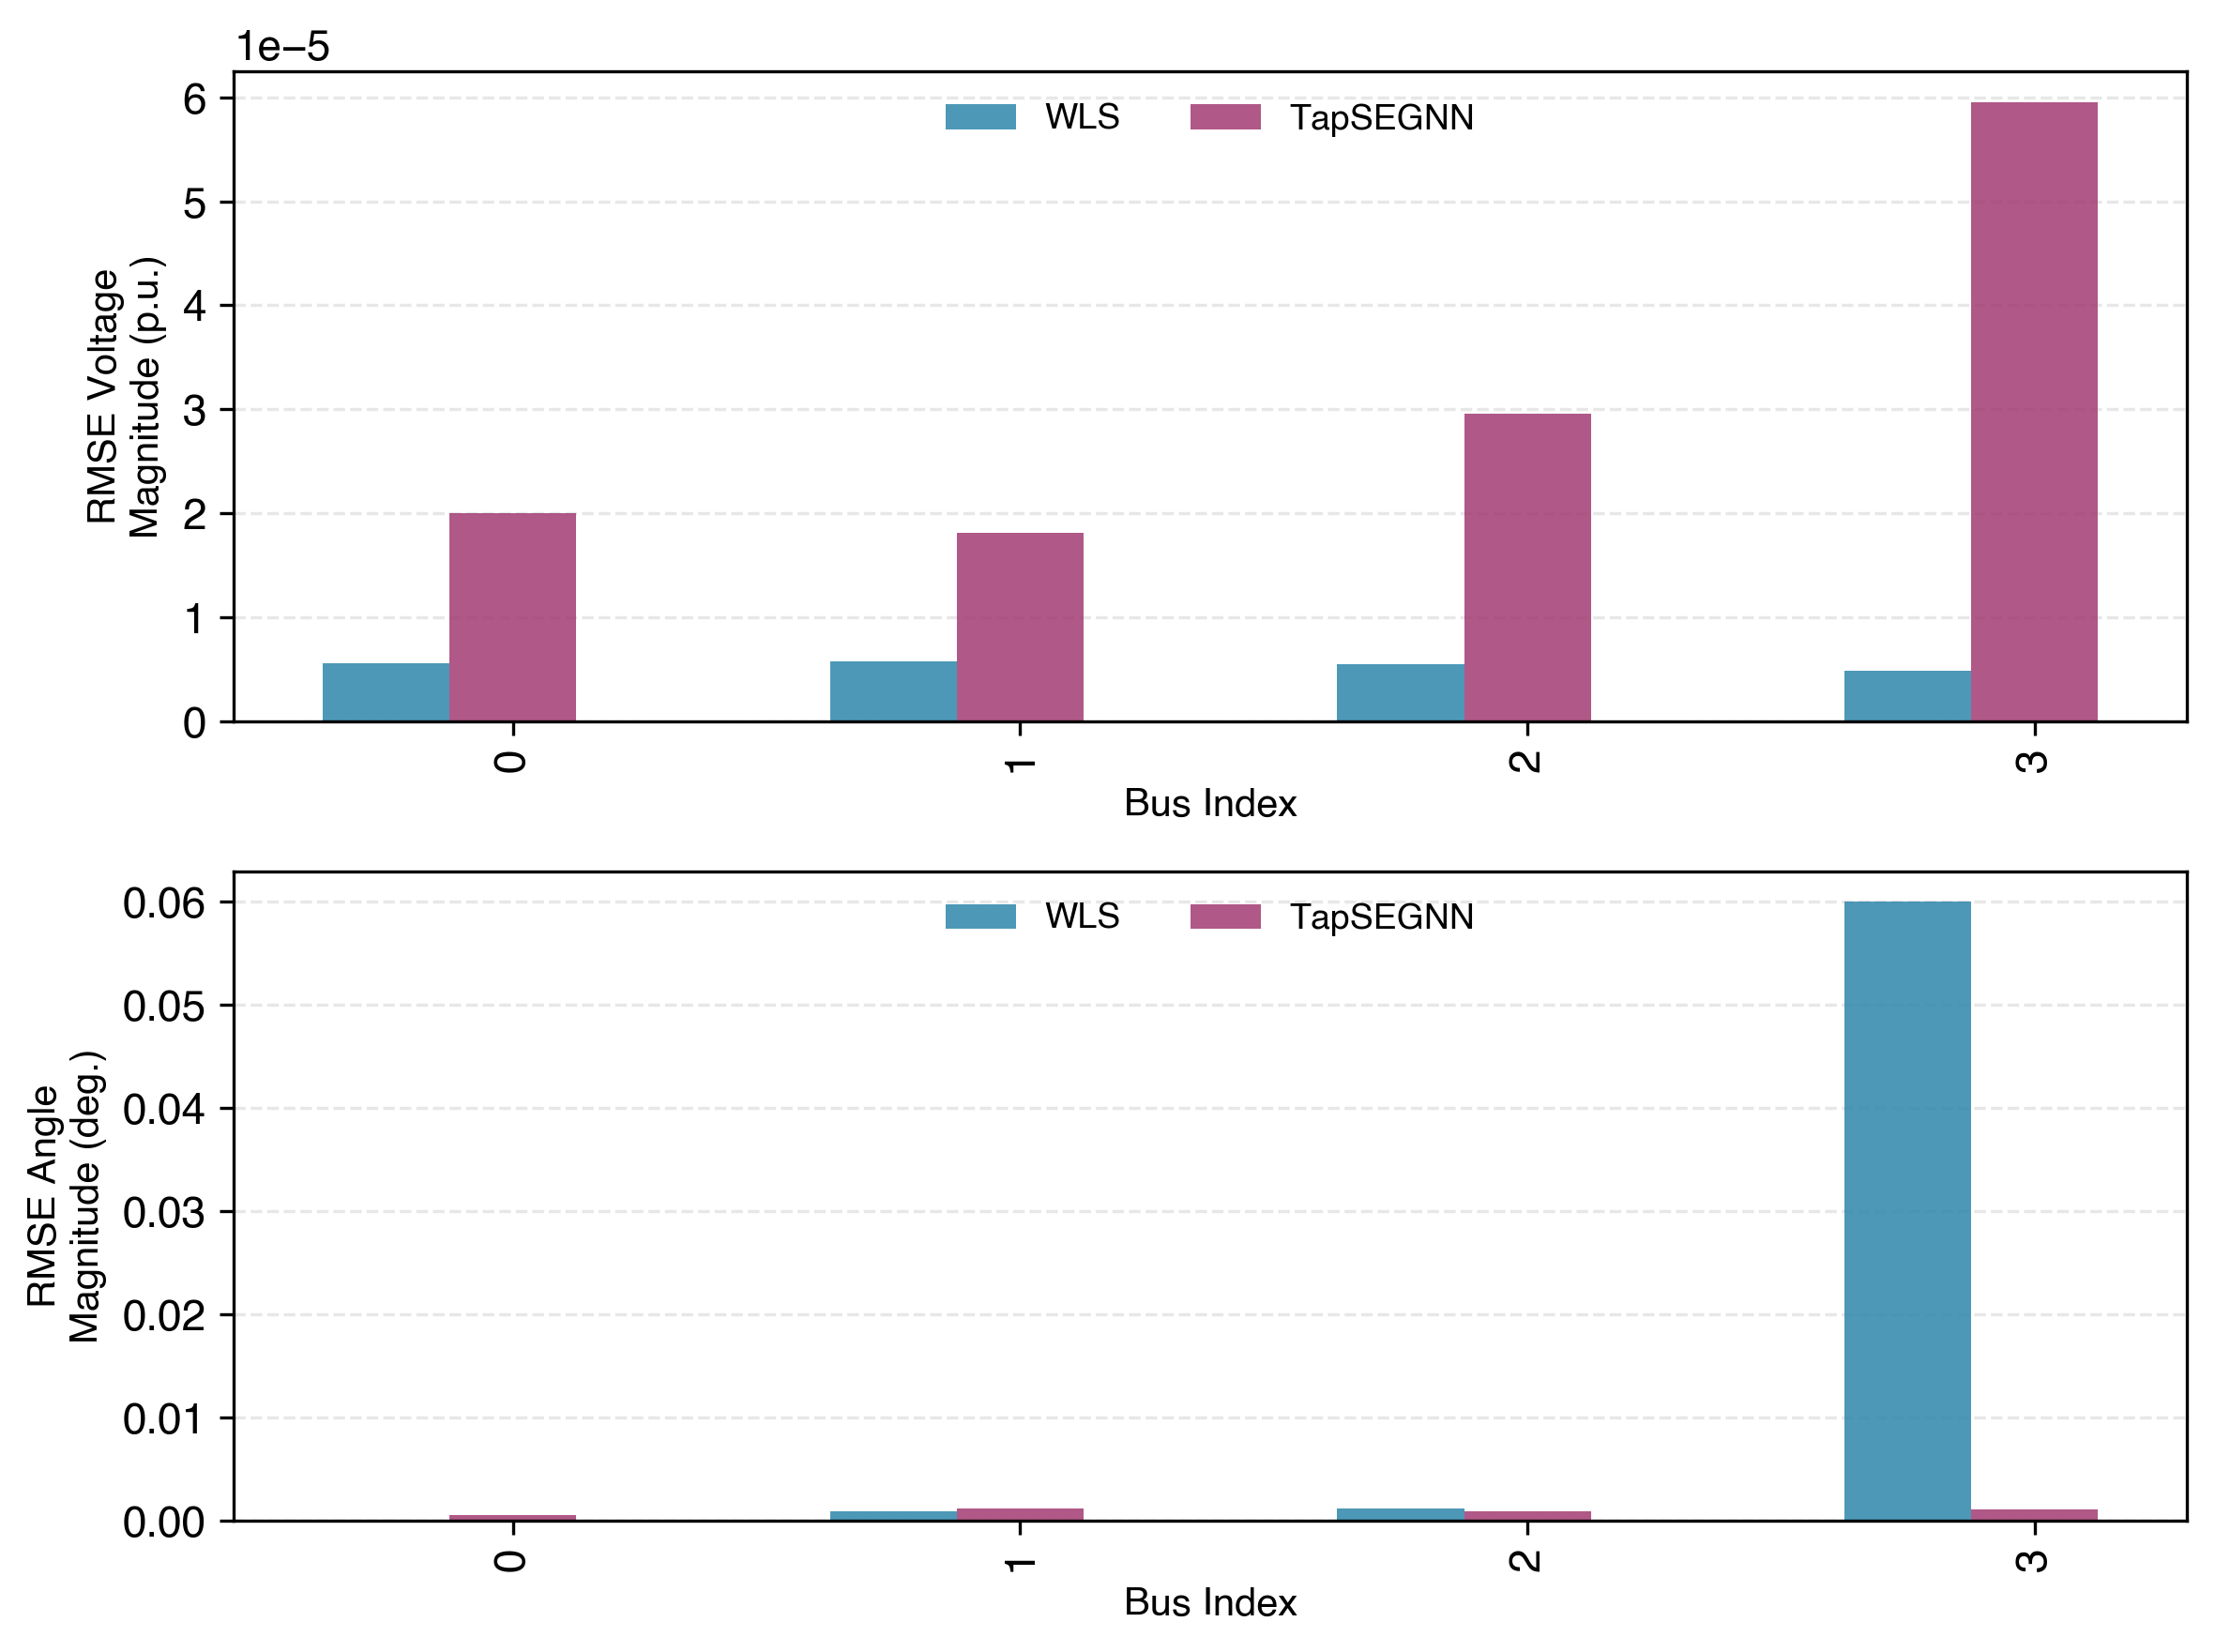

In [12]:
%matplotlib inline
# Set publication-quality style with modern fonts
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Proxima Nova', 'Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['mathtext.fontset'] = 'stixsans'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.dpi'] = 300
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['axes.titleweight'] = 'semibold'

# Create figure with two subplots
fig, ax = plt.subplots(2, 1, figsize=(8, 6))
x = np.arange(len(net.bus))
width = 0.25

# Plot bus-specific voltage RMSE
bars1 = ax[0].bar(x - width, wls_rmse_v, width, label='WLS',
                  color='#2E86AB', alpha=0.85, edgecolor='none')
bars2 = ax[0].bar(x, tapsegnn_rmse_v, width, label='TapSEGNN',
                  color='#A23B72', alpha=0.85, edgecolor='none')
# bars3 = ax[0].bar(x + width, gat_rmse_v, width, label='GAT',
#                   color='#F30E34', alpha=0.85, edgecolor='none')

ax[0].set_xlabel('Bus Index', fontweight='semibold', fontsize=10)
ax[0].set_ylabel('RMSE Voltage\nMagnitude (p.u.)', fontweight='semibold', fontsize=10)
ax[0].legend(loc='upper center', ncol=3, frameon=False, fontsize=9)
ax[0].grid(True, axis='y', linestyle='--', alpha=0.3, zorder=0)
ax[0].set_axisbelow(True)
ax[0].set_xticks(x)
ax[0].set_xticklabels(x, rotation=90)

# Plot bus-specific angle RMSE
bars1a = ax[1].bar(x - width, wls_rmse_a, width, label='WLS',
                   color='#2E86AB', alpha=0.85, edgecolor='none')
bars2a = ax[1].bar(x, tapsegnn_rmse_a, width, label='TapSEGNN',
                   color='#A23B72', alpha=0.85, edgecolor='none')
# bars3a = ax[1].bar(x + width, gat_rmse_a, width, label='GAT',
#                    color='#F30E34', alpha=0.85, edgecolor='none')

ax[1].set_xlabel('Bus Index', fontweight='semibold', fontsize=10)
ax[1].set_ylabel('RMSE Angle\nMagnitude (deg.)', fontweight='semibold', fontsize=10)
ax[1].legend(loc='upper center', ncol=3, frameon=False, fontsize=9)
ax[1].grid(True, axis='y', linestyle='--', alpha=0.3, zorder=0)
ax[1].set_axisbelow(True)
ax[1].set_xticks(x)
ax[1].set_xticklabels(x, rotation=90)

plt.tight_layout()
plt.show()

# # Create figure with two subplots
# fig, ax = plt.subplots(2, 1, figsize=(8, 3))

# x = np.arange(len(net.bus))

# # plot bus-specific voltage RMSE 
# width = 0.6

# bars1 = ax[0].bar(x - width/3, wls_rmse_v, width, label='WLS', 
#                 color='#2E86AB', alpha=0.85, edgecolor='none')
# bars2 = ax[0].bar(x, tapsegnn_rmse_v, width, label='TapSEGNN',
#                 color='#A23B72', alpha=0.85, edgecolor='none')
# bars3 = ax[0].bar(x + width/3, gat_rmse_v, width, label='GAT', 
#                 color="#F30E34")

# ax[0].set_xlabel('Bus Index', fontweight='semibold')
# ax[0].set_ylabel('RMSE Voltage \n Magnitude (p.u.)', fontweight='semibold')
# # ax[0].set_title('Variable V: RMSE Comparison', fontweight='semibold')
# plt.legend(
#     loc='lower center',     # place legend above the plot
#     bbox_to_anchor=(0.5, 0.85),  # center it horizontally, push slightly above
#     ncol=3,                 # number of columns (adjust depending on how many labels you have)
#     frameon=False           # optional: remove legend box frame
# )
# ax[0].grid(True, axis='y', linestyle='--', alpha=0.3, zorder=0)
# ax[0].set_axisbelow(True)


# # plot bus-specific angle RMSE 
# width = 0.6

# bars1a = ax[1].bar(x - width/3, wls_rmse_a, width, label='WLS', 
#                 color='#2E86AB', alpha=0.85, edgecolor='none')
# bars2a = ax[1].bar(x, tapsegnn_rmse_a, width, label='TapSEGNN',
#                 color='#A23B72', alpha=0.85, edgecolor='none')
# bars3a = ax[1].bar(x + width/3, gat_rmse_a, width, label='GAT', 
#                 color="#F30E34")

# ax[1].set_xlabel('Bus Index', fontweight='semibold')
# ax[1].set_ylabel('RMSE Angle \n Magnitude (deg.)', fontweight='semibold')
# plt.legend(
#     loc='lower center',     # place legend above the plot
#     bbox_to_anchor=(0.5, 0.85),  # center it horizontally, push slightly above
#     ncol=3,                 # number of columns (adjust depending on how many labels you have)
#     frameon=False           # optional: remove legend box frame
# )
# ax[1].grid(True, axis='y', linestyle='--', alpha=0.3, zorder=0)
# ax[1].set_axisbelow(True)
